<div class="alert">Get the residuals from ZTF-sHG1G2 for Dima's method</div>

In [1]:
import os
import time
import sys
sys.path.append("..")


import numpy as np

import ssptools
from astropy.coordinates import SkyCoord
import rocks

from fink_utils.sso.spins import estimate_sso_params, func_sshg1g2 #, func_hg1g2, cos_aspect_angle
from fink_utils.sso.periods import estimate_synodic_period 
from fink_utils.sso.utils import (compute_light_travel_correction, estimate_axes_ratio)

import matplotlib.pyplot as plt


# import seaborn as sns
# sns.set_context("poster")

In [2]:
fink_colors = ["#15284F", "#F5622E"]

# Functions to add to fink-utils

In [3]:
def angle_between_vectors(v1, v2):
    """
    Compute the angle between two 3D vectors.

    Parameters
    ----------
    v1 : list or np.ndarray
        The first 3D vector.
    v2 : list or np.ndarray
        The second 3D vector.

    Returns
    -------
    float
        The angle between the two vectors in radians.
    """
    v1 = np.array(v1)
    v2 = np.array(v2)

    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    cos_theta = dot_product / (norm_v1 * norm_v2)
    angle = np.arccos(np.clip(cos_theta, -1.0, 1.0))  # Clip to handle numerical issues

    return angle


# Example usage
# v1 = [1.0, 0, 0]
# v2 = [-1.0, -1.0, 1]
# angle = angle_between_vectors(v1, v2)
# print(f"The angle between the vectors is {np.degrees(angle):.2f} degrees")

def synodic_to_sidereal(synodic_period, X):
    """
    Convert synodic rotation period to sidereal rotation period.

    TBD

    Parameters
    ----------
    synodic_period : float
        Synodic rotation period in days.

    Returns
    -------
    sidereal_period : float
        Sidereal rotation period in days.
    """
    sidereal_period = synodic_period
    return sidereal_period

# Target definition

In [4]:
ssnamenr = 5209
ssnamenr = 136108 # KBO = fixed = Haumea
# ssnamenr = 186153 # High frequency observation
# ssnamenr = 223 # Example article 
# ssnamenr = 9799 # JTO lotta obs

# ssnamenr = 17365 # 1978VF11 Thymbareus

ssnamenr = 17365

ssocard = rocks.Rock(ssnamenr)
name, num = ssocard.name, ssocard.number
name, num

('Thymbraeus', 17365)

## Period estimation

In [5]:
flavor = "SHG1G2"

period_range = (1 / 24, 7)  # 1hour to 7 days

t0 = time.time()
period, chi2red, frequency, power, model, pdf = estimate_synodic_period(
    ssnamenr,
    flavor=flavor,
    Nterms_base=1,
    period_range=period_range,
    return_extra_info=True,
)

In [6]:
print(
    "[{:.2f} seconds] model={}: period={:.2f} hours (chi2red={:.2f}) -- SsODNet: period={:.2f} h ({:s})".format(
        time.time() - t0,
        flavor,
        period,
        chi2red,
        ssocard.spin[0].period.value,
        ",".join(ssocard.spin[0].bibref.bibcode),
    )
)

[11.38 seconds] model=SHG1G2: period=12.67 hours (chi2red=3.06) -- SsODNet: period=12.67 h (2023A&A...675A..24D)


In [ ]:
fname = f'{ssnamenr}.obs'

# Reformat for Dima
pdf['na'] = pdf.H*0.
cols = ['sso_name', 'i:jd', 'na', 'na', 'residuals', 'i:sigmapsf', 'i:fid', 'na', 'na', 'Dobs', 'Dhelio', 'Phase']
df = pdf[cols]
df['sso_name'] = ssnamenr
df.to_string( os.path.join( '..', '..', 'data', 'dima', fname), header=None, index=None)

/tmp/ipykernel_181845/2092116238.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sso_name'] = ssnamenr


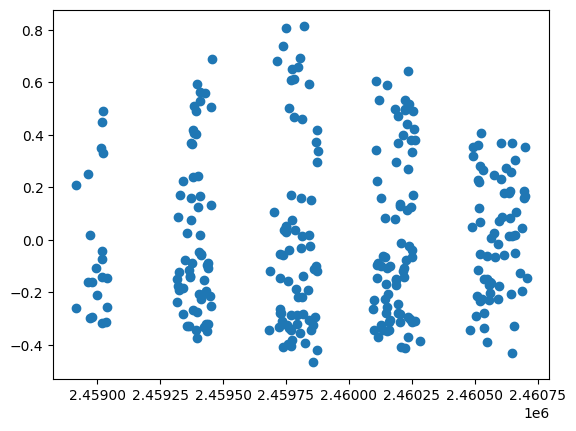

In [10]:
fig, ax = plt.subplots()

ax.scatter( df['i:jd'], pdf['residuals'])